In [2]:
import pandas as pd

df = pd.read_excel('skin_irritation.xlsx', sheet_name=2)

In [5]:
import pandas as pd

# 1. 데이터 로드 (세 번째 시트인 Data_invivo를 로드)
# 엑셀 파일 이름이 'skin_irritation.xlsx'인지 꼭 확인하세요!
df = pd.read_excel('skin_irritation.xlsx', sheet_name=2)

# (ㄱ, ㄴ, ㄷ) 필터링
# Mixture 컬럼이 'Chemical'이고, Species 컬럼이 'Human'인 데이터만 추출
df_filtered = df[
    (df['Mixture'] == 'Chemical') & 
    (df['Species'] == 'Human') & 
    (df['Endpoint'] == 'Qualitative classification')
].copy()

# Response 컬럼에서 'Not classified'이면 0, 그 외의 값은 1로 설정
# (NaN 값이 있을 수 있으므로 처리 추가)
df_filtered['label'] = df_filtered['Response'].apply(lambda x: 0 if x == 'Not classified' else 1)

# 필요한 컬럼만 남기기 (SMILES와 label)
df_task1 = df_filtered[['SMILES', 'label']].dropna(subset=['SMILES']).reset_index(drop=True)

print(f"필터링 후 남은 데이터 개수: {len(df_task1)}")
print(df_task1.head())

필터링 후 남은 데이터 개수: 70
                                          SMILES  label
0                                        CC(O)CO      0
1                                      CCCCCCC=O      1
2                       CCCCCCCCCCCCCC(=O)OC(C)C      0
3  C*.C*.OCCOCCO |lp:4:2,7:2,10:2,m:1:5.6,3:8.9|      0
4                                    [OH-].[Na+]      1


In [6]:
from rdkit import Chem
from rdkit.Chem import SaltRemover

# (ㄱ, ㄴ) 염 제거 및 SMILES 표준화 함수
def clean_smiles(smiles):
    try:
        remover = SaltRemover.SaltRemover()
        mol = Chem.MolFromSmiles(smiles)
        if mol:
            mol_clean = remover.StripMol(mol) # 염 제거
            return Chem.MolToSmiles(mol_clean, isomericSmiles=False) # 표준화된 SMILES
    except:
        return None
    return None

# 표준화 적용
df_task1['SMILES_clean'] = df_task1['SMILES'].apply(clean_smiles)
df_task1 = df_task1.dropna(subset=['SMILES_clean'])

# (ㄷ) 중복 제거 로직
# 1. SMILES와 label이 모두 동일한 경우 -> 1개만 남기기
df_task2 = df_task1.drop_duplicates(subset=['SMILES_clean', 'label'])

# 2. SMILES는 동일한데 label이 다른 경우 -> 아예 제거 (데이터 모순)
df_task2 = df_task2.drop_duplicates(subset=['SMILES_clean'], keep=False).reset_index(drop=True)

# (ㄹ) 중복 제거 후 Label Balance 체크
print("최종 데이터 레이블 분포:")
print(df_task2['label'].value_counts())

최종 데이터 레이블 분포:
label
0    45
1    11
Name: count, dtype: int64


[12:09:03] Explicit valence for atom # 2 B, 5, is greater than permitted


In [8]:
import numpy as np
from rdkit.ML.Descriptors import MoleculeDescriptors
from rdkit.Chem import Descriptors
from sklearn.linear_model import LogisticRegression

# (ㄱ) RDKit Descriptor 계산 설정
desc_names = [d[0] for d in Descriptors._descList]
calc = MoleculeDescriptors.MolecularDescriptorCalculator(desc_names)

def get_desc_values(smiles):
    mol = Chem.MolFromSmiles(smiles)
    return calc.CalcDescriptors(mol) if mol else [None] * len(desc_names)

# 계산 수행 및 데이터프레임 생성
desc_data = df_task2['SMILES_clean'].apply(get_desc_values).tolist()
X_all = pd.DataFrame(desc_data, columns=desc_names)
y = df_task2['label']

# 결측치(NaN)나 무한대(Inf)가 포함된 컬럼 제거
X_all = X_all.replace([np.inf, -np.inf], np.nan).dropna(axis=1)

# (ㄴ, ㄷ) 각 Descriptor 1개씩 사용하여 성능 측정
results = {}

for col in X_all.columns:
    model = LogisticRegression(max_iter=1000)
    X_single = X_all[[col]] # 단일 변수 추출
    
    model.fit(X_single, y)
    score = model.score(X_single, y) # 전체 데이터에 대한 Accuracy
    results[col] = score

# 가장 성능이 높은 Descriptor 찾기
best_feature = max(results, key=results.get)
best_score = results[best_feature]

print(f"\n최고 성능 Descriptor: {best_feature}")
print(f"해당 Descriptor의 훈련 Accuracy: {best_score:.4f}")

# (선택) 해당 Descriptor로 최종 모델 재확인
final_model = LogisticRegression().fit(X_all[[best_feature]], y)


최고 성능 Descriptor: SlogP_VSA4
해당 Descriptor의 훈련 Accuracy: 0.8393


In [19]:
#조건을 다르게해서 계속 실행해보기-Discriptor별로 실행해보기
#confusion matrix를 이용해 label별로 예측 정확도를 본다
#semsitive, specificity 같이 여러개를 실행해본다

In [25]:
!pip install seaborn

C:\Users\DS\miniconda3\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
C:\Users\DS\miniconda3\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
C:\Users\DS\miniconda3\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 44537 (\N{HANGUL SYLLABLE GEUG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
C:\Users\DS\miniconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\DS\miniconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\DS\miniconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44050 (\N

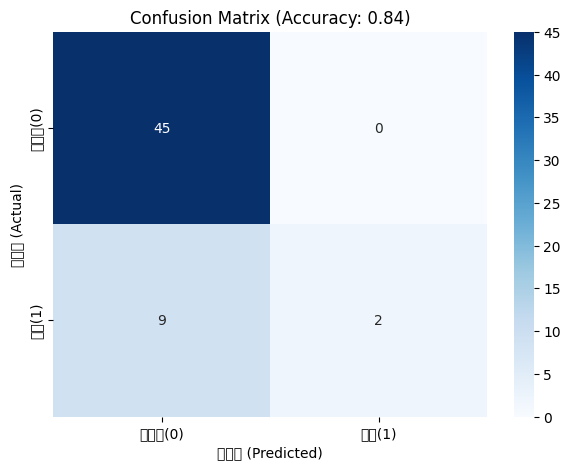

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score

# 1. 모델 예측값 생성 (위에서 학습시킨 final_model 사용)
# 여기서는 학습 데이터(X_all[[best_feature]])에 대한 예측을 진행합니다.
y_pred = final_model.predict(X_all[[best_feature]])

# 2. Confusion Matrix 계산
cm = confusion_matrix(y, y_pred)

# 3. 그래프 그리기
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['비자극(0)', '자극(1)'], 
            yticklabels=['비자극(0)', '자극(1)'])

plt.title(f'Confusion Matrix (Accuracy: {accuracy_score(y, y_pred):.2f})')
plt.xlabel('예측값 (Predicted)')
plt.ylabel('실제값 (Actual)')
plt.show()

In [30]:
# (1)이 (1)-(1)인게 2개 아닌게 9개이기 때문에 잘못된것 = 데이터의 문제
# 보고서를 작성할 때 이런 오류가 있어서 어떤 노력을 했느지까지 적어주기
# 예를들어,새로운 데이터를 찾아봤다, 다른 dataset으로 분석해보았다 등. 

In [27]:
!pip install statsmodels

   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ------------------- -------------------- 4.7/9.5 MB 27.3 MB/s eta 0:00:01
   -------------------------- ------------- 6.3/9.5 MB 16.2 MB/s eta 0:00:01
   -------------------------------- ------- 7.9/9.5 MB 13.1 MB/s eta 0:00:01
   ---------------------------------------  9.4/9.5 MB 11.6 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 11.0 MB/s  0:00:00

   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [sta

RuntimeError: `logistic=True` requires statsmodels, an optional dependency, to be installed.

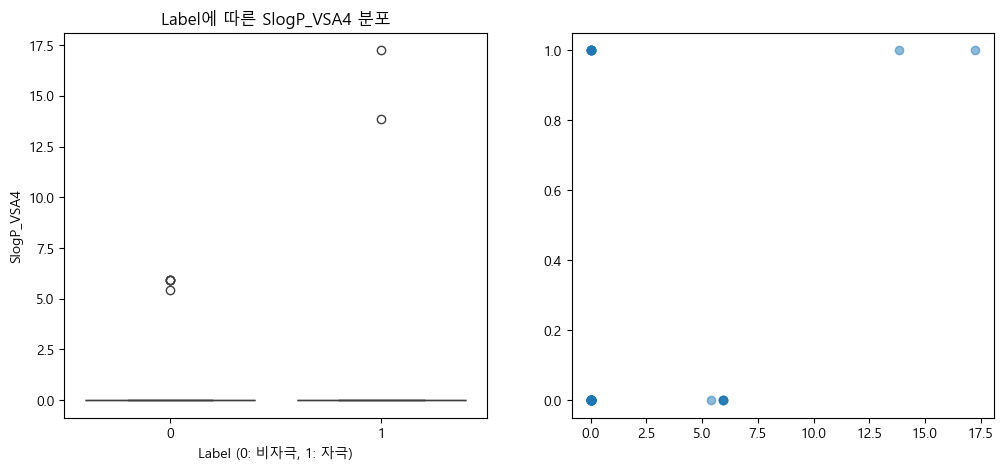

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정 (환경에 따라 필요할 수 있음)
plt.rcParams['font.family'] = 'Malgun Gothic' # 윈도우 기준

# 그래프 크기 설정
plt.figure(figsize=(12, 5))

# 1. Box Plot: 그룹별 Descriptor 분포 확인
plt.subplot(1, 2, 1)
sns.boxplot(x='label', y=best_feature, data=X_all.assign(label=y))
plt.title(f'Label에 따른 {best_feature} 분포')
plt.xlabel('Label (0: 비자극, 1: 자극)')

# 2. Logistic Regression Curve: Descriptor에 따른 예측 확률
plt.subplot(1, 2, 2)
sns.regplot(x=X_all[best_feature], y=y, logistic=True, 
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title(f'{best_feature}의 로지스틱 회귀 곡선')
plt.xlabel(best_feature)
plt.ylabel('자극성 확률 (Probability)')

plt.tight_layout()
plt.show()

In [ ]:
'''
실습 파일: 'skin_irritation.xlsx'
1) label 정의
 (ㄱ) mixture 컬럼: chemical

 (ㄴ) species 컬럼: human

 (ㄷ) endpoint 컬럼의 qualitative classificaiton 결과만 y로 사용. response 컬럼에서 not classified인 경우 label을 0, 그 외 값에 대해서는 1로 설정.

In [17]:
import pandas as pd
#데이터 로드
df = pd.read_excel('skin_irritation.xlsx', sheet_name=2)
#데이터 필터링
query_df = df[(df['Mixture'] == 'Chemical') & (df['Species'] == 'human') & (df['Endpoint'] == 'qualitative classificaiton')].copy
#label 생성 및 필요 컬럼 추출
# Response 컬럼에서 'Not classified'이면 0, 그 외의 값은 1로 설정
df_filtered['label'] = df_filtered['Response'].apply(lambda x: 0 if x == 'Not classified' else 1)
# 필요한 컬럼만 남기기 (SMILES와 label)
#df_task1 = df_filtered[['SMILES', 'label']]
#print('df_task1', df_task1)
df_task2 = df_filtered.dropna(subset=['SMILES'])
print('df_task2', df_task2)


df_task1                       Record_ID Data_Type Formulation_ID Formulation_Name  \
82    skin_irritation_invivo_84   In Vivo            NaN              NaN   
100   skin_irritation_invivo_12   In Vivo            NaN              NaN   
130   skin_irritation_invivo_33   In Vivo            NaN              NaN   
132   skin_irritation_invivo_67   In Vivo            NaN              NaN   
146   skin_irritation_invivo_63   In Vivo            NaN              NaN   
...                         ...       ...            ...              ...   
1849  skin_irritation_invivo_77   In Vivo            NaN              NaN   
1851  skin_irritation_invivo_46   In Vivo            NaN              NaN   
1857  skin_irritation_invivo_76   In Vivo            NaN              NaN   
1859   skin_irritation_invivo_8   In Vivo            NaN              NaN   
1861  skin_irritation_invivo_39   In Vivo            NaN              NaN   

                                       Chemical_Name       CASRN  

In [11]:
'''
2) 데이터 중복 체크

 (ㄱ) smiles 코드에서 염 제거하고 단일 구조만 저장

 (ㄴ) rdkit을 이용해서 smiles 코드 표준화

 (ㄷ) smiles 코드가 동일한데 label 값이 다른 물질 제거. label 값도 동일하고 smiles 코드도 동일한 경우, 1개만 남기기.

 (ㄹ) 중복 제거된 후 label balance 체크 (label 컬럼 '1' 개수, '0' 개수)
 '''

"\n2) 데이터 중복 체크\n\n (ㄱ) smiles 코드에서 염 제거하고 단일 구조만 저장\n\n (ㄴ) rdkit을 이용해서 smiles 코드 표준화\n\n (ㄷ) smiles 코드가 동일한데 label 값이 다른 물질 제거. label 값도 동일하고 smiles 코드도 동일한 경우, 1개만 남기기.\n\n (ㄹ) 중복 제거된 후 label balance 체크 (label 컬럼 '1' 개수, '0' 개수)\n "

In [ ]:
from rdkit import chem
from rdkit.Chem import SlatRemover

# (ㄱ, ㄴ) 염 제거 및 SMILES 표준화 함수
df clean_smiles(smiles):
    try:
        remover = SaltRemover.SaltRemover()
        mol = Chem.MolFromSmiles(smiles)
        if mol:
            ol_clean = remover.StripMol(mol) #염제거